# Neural Network Results — Phase 6.1

FNN (32→16→8) and LSTM (2-layer, seq_len=21) trained with Optuna HP tuning, 5-seed ensemble, MSE loss on log-space target, QLIKE early stopping.

**Sections:**
1. Load artifacts
2. Full model ranking (all 10 models)
3. Best hyperparameters
4. Prediction distributions
5. Per-symbol performance
6. Time-series diagnostics
7. Residual analysis
8. Summary

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

DATA = Path("../data/processed")
PREDS = DATA / "predictions"
MODELS = DATA / "models"
SPLITS = DATA / "splits"

# Load all predictions
fnn = pl.read_parquet(PREDS / "fnn.parquet")
lstm = pl.read_parquet(PREDS / "lstm.parquet")
lgbm = pl.read_parquet(PREDS / "lgbm.parquet")
baselines = pl.read_parquet(PREDS / "baselines.parquet")
all_preds = pl.concat([baselines, lgbm, fnn, lstm])

# Load params
with open(MODELS / "fnn_best_params.json") as f:
    fnn_params = json.load(f)
with open(MODELS / "lstm_best_params.json") as f:
    lstm_params = json.load(f)
with open(SPLITS / "scaler_stats.json") as f:
    train_mean_rv = json.load(f)["__train_mean_rv__"]

print(f"FNN: {len(fnn):,} rows | LSTM: {len(lstm):,} rows")
print(f"All predictions: {len(all_preds):,} rows, {all_preds['model'].n_unique()} models")
print(f"train_mean_rv = {train_mean_rv:.4f}")

FNN: 36,924 rows | LSTM: 33,084 rows
All predictions: 364,327 rows, 10 models
train_mean_rv = 0.1748


## 2. Full Model Ranking

All 10 models ranked by QLIKE. Metrics: QLIKE (primary), MSE, MAE, MAPE, R²_OOS (Gu/Kelly/Xiu).

In [2]:
from theta.modeling.evaluation import qlike, mse, mae, mape, r2_oos

MODEL_ORDER = ["LSTM", "LightGBM", "LogHAR", "HARQ", "SHAR", "LevHAR", "HAR", "FNN", "GARCH", "AR5"]

rows = []
for name in MODEL_ORDER:
    sub = all_preds.filter(pl.col("model") == name)
    y = sub["y_true"].to_numpy()
    yhat = sub["y_pred"].to_numpy()
    rows.append({
        "Model": name, "n": len(sub),
        "QLIKE": qlike(y, yhat), "MSE": mse(y, yhat),
        "MAE": mae(y, yhat), "MAPE": mape(y, yhat),
        "R2_OOS": r2_oos(y, yhat, train_mean_rv),
    })

print(f"{'Model':<12} {'n':>7} {'QLIKE':>8} {'MSE':>10} {'MAE':>8} {'MAPE%':>8} {'R²_OOS':>8}")
print("-" * 70)
for r in rows:
    marker = " ◀" if r["Model"] in ("FNN", "LSTM") else ""
    print(f"{r['Model']:<12} {r['n']:>7,} {r['QLIKE']:>8.4f} {r['MSE']:>10.6f} "
          f"{r['MAE']:>8.4f} {r['MAPE']:>8.2f} {r['R2_OOS']:>8.4f}{marker}")

loghar_q = [r for r in rows if r["Model"] == "LogHAR"][0]["QLIKE"]
lstm_q = [r for r in rows if r["Model"] == "LSTM"][0]["QLIKE"]
fnn_q = [r for r in rows if r["Model"] == "FNN"][0]["QLIKE"]
lgbm_q = [r for r in rows if r["Model"] == "LightGBM"][0]["QLIKE"]
print(f"\nLSTM vs LogHAR: {(loghar_q - lstm_q) / loghar_q * 100:.1f}% QLIKE reduction")
print(f"LSTM vs LightGBM: {(lgbm_q - lstm_q) / lgbm_q * 100:.1f}% QLIKE reduction")
print(f"FNN vs LogHAR: {(loghar_q - fnn_q) / loghar_q * 100:.1f}% (worse)")

Model              n    QLIKE        MSE      MAE    MAPE%   R²_OOS
----------------------------------------------------------------------
LSTM          33,084   0.0160   0.001485   0.0106     8.39   0.9653 ◀
LightGBM      36,924   0.0215   0.002583   0.0164    13.22   0.9404
LogHAR        36,811   0.0259   0.002994   0.0167    13.32   0.9310
HARQ          36,924   0.0263   0.003024   0.0164    14.08   0.9302
SHAR          36,924   0.0264   0.003019   0.0162    14.25   0.9303
LevHAR        36,924   0.0265   0.003022   0.0162    14.38   0.9303
HAR           36,924   0.0265   0.003018   0.0163    14.39   0.9303
FNN           36,924   0.0285   0.006273   0.0239    16.41   0.8552 ◀
GARCH         36,924   0.2240   0.035877   0.0869    80.99   0.1721
AR5           35,964   0.3691   0.028390   0.0954   148.42   0.3367

LSTM vs LogHAR: 38.1% QLIKE reduction
LSTM vs LightGBM: 25.5% QLIKE reduction
FNN vs LogHAR: -10.1% (worse)


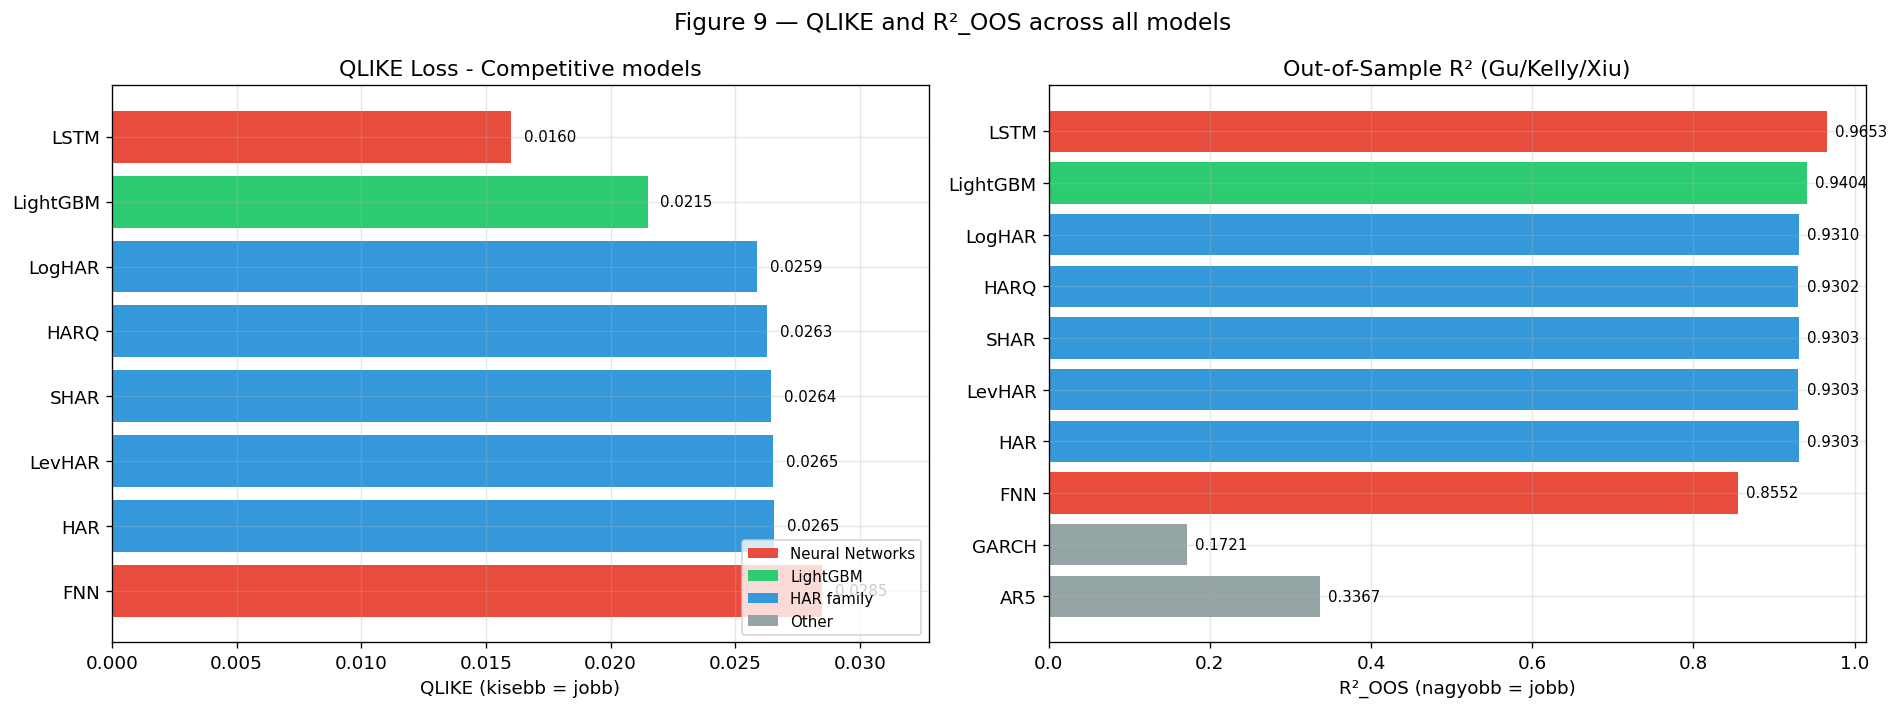

Note: GARCH (QLIKE=0.2240) and AR5 (QLIKE=0.3691) omitted from the left panel - values 10-20x larger would distort the scale.


In [3]:
# Bar chart: QLIKE and R²_OOS for all models
# GARCH and AR5 excluded from QLIKE chart (0.224 and 0.369 distort the scale)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Only competitive models for QLIKE
competitive = [r for r in rows if r["Model"] not in ("GARCH", "AR5")]
models_q = [r["Model"] for r in competitive]
colors_q = ["#e74c3c" if m in ("FNN", "LSTM") else "#2ecc71" if m == "LightGBM"
            else "#3498db" for m in models_q]

# QLIKE (competitive models only)
ax = axes[0]
vals = [r["QLIKE"] for r in competitive]
bars = ax.barh(models_q, vals, color=colors_q)
ax.set_xlabel("QLIKE (kisebb = jobb)")
ax.set_title("QLIKE Loss - Competitive models")
ax.invert_yaxis()
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2, f"{v:.4f}", va="center", fontsize=9)
ax.set_xlim(0, max(vals) * 1.15)

# R² OOS (all models — scale is 0-1, no distortion)
models_all = [r["Model"] for r in rows]
colors_all = ["#e74c3c" if m in ("FNN", "LSTM") else "#2ecc71" if m == "LightGBM"
              else "#3498db" if m in ("LogHAR", "HAR", "SHAR", "LevHAR", "HARQ")
              else "#95a5a6" for m in models_all]

ax = axes[1]
vals = [r["R2_OOS"] for r in rows]
bars = ax.barh(models_all, vals, color=colors_all)
ax.set_xlabel("R²_OOS (nagyobb = jobb)")
ax.set_title("Out-of-Sample R² (Gu/Kelly/Xiu)")
ax.invert_yaxis()
for bar, v in zip(bars, vals):
    ax.text(max(bar.get_width(), 0) + 0.01, bar.get_y() + bar.get_height()/2, f"{v:.4f}", va="center", fontsize=9)

from matplotlib.patches import Patch
legend = [Patch(facecolor="#e74c3c", label="Neural Networks"),
          Patch(facecolor="#2ecc71", label="LightGBM"),
          Patch(facecolor="#3498db", label="HAR family"),
          Patch(facecolor="#95a5a6", label="Other")]
axes[0].legend(handles=legend, loc="lower right", fontsize=9)

fig.suptitle("Figure 9 — QLIKE and R²_OOS across all models", fontsize=14)
plt.tight_layout()
plt.show()
print("Note: GARCH (QLIKE=0.2240) and AR5 (QLIKE=0.3691) omitted from the left panel - values 10-20x larger would distort the scale.")

## 3. Best Hyperparameters

FNN: fixed architecture (32→16→8), tuned dropout/lr/batch/wd.
LSTM: tuned hidden_size, num_layers, dropout, lr, batch, wd.

In [4]:
print("FNN Best Hyperparameters (Optuna, 10 trials x 3-fold purged CV):")
print(f"  Architecture: 44 → 32 → 16 → 8 → 1 (fixed, per Gu/Kelly/Xiu NN3)")
print(f"  Dropout:      {fnn_params['dropout']:.4f}")
print(f"  Learning rate: {fnn_params['lr']:.6f}")
print(f"  Batch size:   {fnn_params['batch_size']}")
print(f"  Weight decay: {fnn_params['weight_decay']:.2e}")
print(f"  Activation:   ReLU + BatchNorm")
print(f"  Optimizer:    AdamW")
print(f"  Best CV QLIKE: 0.0313")

print(f"\nLSTM Best Hyperparameters (Optuna, 10 trials x 3-fold purged CV):")
print(f"  Hidden size:  {lstm_params['hidden_size']}")
print(f"  Num layers:   {lstm_params['num_layers']}")
print(f"  Seq length:   21 (fixed — matches RV target horizon)")
print(f"  Dropout:      {lstm_params['dropout']:.4f}")
print(f"  Learning rate: {lstm_params['lr']:.6f}")
print(f"  Batch size:   {lstm_params['batch_size']}")
print(f"  Weight decay: {lstm_params['weight_decay']:.2e}")
print(f"  Optimizer:    AdamW")
print(f"  Best CV QLIKE: 0.0174")

FNN Best Hyperparameters (Optuna, 10 trials x 3-fold purged CV):
  Architecture: 44 → 32 → 16 → 8 → 1 (fixed, per Gu/Kelly/Xiu NN3)
  Dropout:      0.1236
  Learning rate: 0.001165
  Batch size:   512
  Weight decay: 7.82e-05
  Activation:   ReLU + BatchNorm
  Optimizer:    AdamW
  Best CV QLIKE: 0.0313

LSTM Best Hyperparameters (Optuna, 10 trials x 3-fold purged CV):
  Hidden size:  124
  Num layers:   2
  Seq length:   21 (fixed — matches RV target horizon)
  Dropout:      0.3917
  Learning rate: 0.000691
  Batch size:   256
  Weight decay: 1.04e-05
  Optimizer:    AdamW
  Best CV QLIKE: 0.0174


## 4. Prediction Distributions

LSTM vs LightGBM vs LogHAR: histograms, scatter (pred vs actual), residual time series.

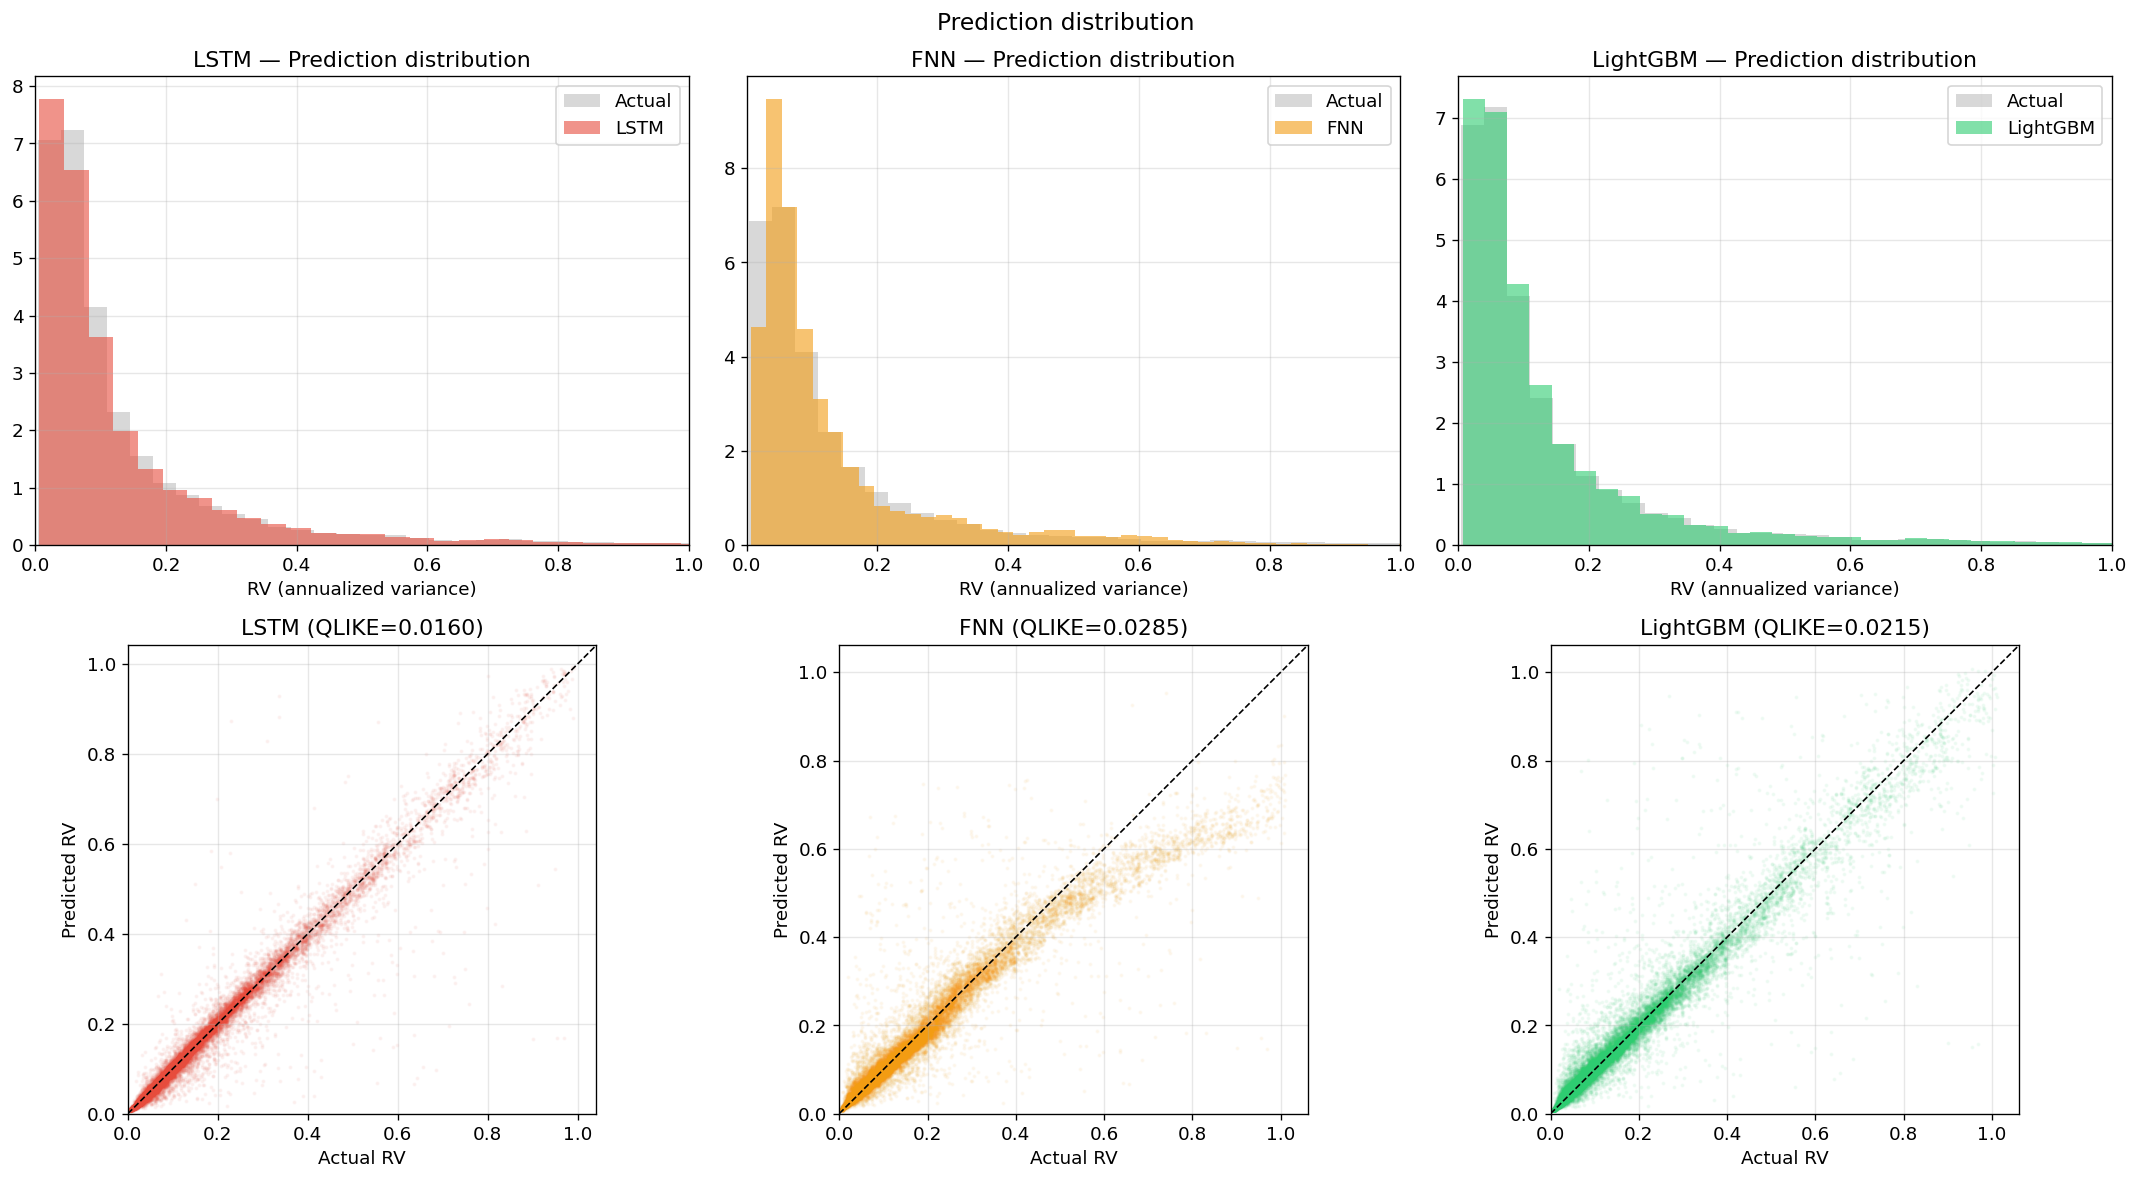

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

loghar = baselines.filter(pl.col("model") == "LogHAR")
focus = [("LSTM", lstm, "#e74c3c"), ("FNN", fnn, "#f39c12"), ("LightGBM", lgbm, "#2ecc71")]

# Row 1: Prediction histograms
for i, (name, df, color) in enumerate(focus):
    ax = axes[0, i]
    y = df["y_true"].to_numpy()
    yhat = df["y_pred"].to_numpy()
    ax.hist(y, bins=80, alpha=0.3, color="gray", density=True, label="Actual")
    ax.hist(yhat, bins=80, alpha=0.6, color=color, density=True, label=name)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("RV (annualized variance)")
    ax.set_title(f"{name} — Prediction distribution")
    ax.legend()

# Row 2: Scatter (pred vs actual)
for i, (name, df, color) in enumerate(focus):
    ax = axes[1, i]
    y = df["y_true"].to_numpy()
    yhat = df["y_pred"].to_numpy()
    clip = np.percentile(y, 99)
    mask = (y < clip) & (yhat < clip)
    ax.scatter(y[mask], yhat[mask], alpha=0.05, s=2, color=color)
    lim = max(y[mask].max(), yhat[mask].max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Actual RV")
    ax.set_ylabel("Predicted RV")
    ax.set_title(f"{name} (QLIKE={qlike(y, yhat):.4f})")
    ax.set_aspect("equal")

fig.suptitle("Prediction distribution", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Per-Symbol Performance

LSTM vs LightGBM vs LogHAR per-symbol QLIKE scatter. Points below the diagonal = LSTM wins.

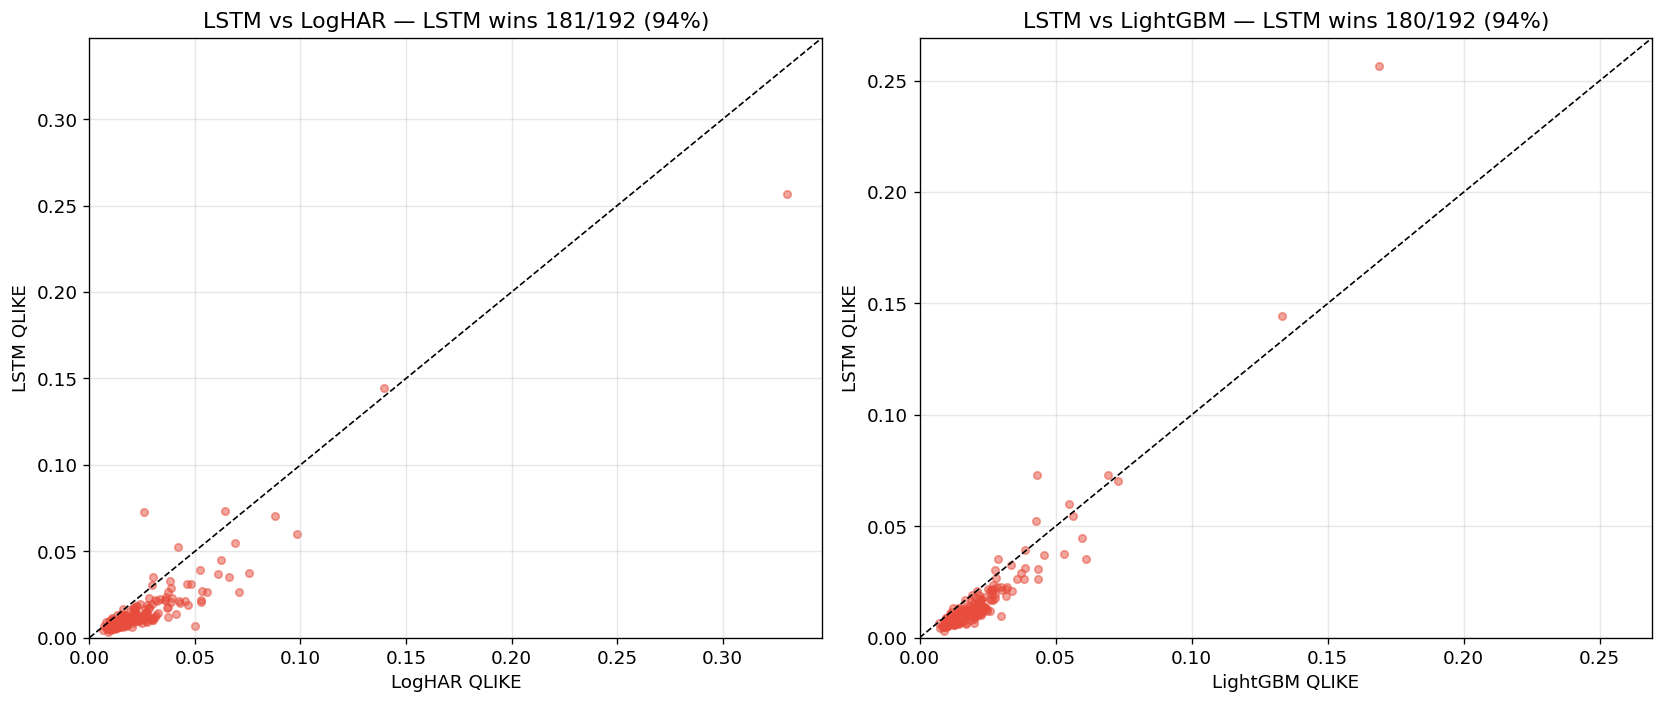

In [6]:
def symbol_qlike(df):
    results = {}
    for sym in df["symbol"].unique().sort().to_list():
        sub = df.filter(pl.col("symbol") == sym)
        y = sub["y_true"].to_numpy()
        yhat = np.clip(sub["y_pred"].to_numpy(), 1e-8, None)
        ratio = y / yhat
        results[sym] = float(np.mean(ratio - np.log(ratio) - 1))
    return results

lstm_sym = symbol_qlike(lstm)
lgbm_sym = symbol_qlike(lgbm)
loghar_sym = symbol_qlike(loghar)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LSTM vs LogHAR
common = sorted(set(lstm_sym) & set(loghar_sym))
lx = [loghar_sym[s] for s in common]
ly = [lstm_sym[s] for s in common]
ax = axes[0]
ax.scatter(lx, ly, alpha=0.5, s=20, color="#e74c3c")
lim = max(max(lx), max(ly)) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("LogHAR QLIKE"); ax.set_ylabel("LSTM QLIKE")
wins = sum(1 for a, b in zip(ly, lx) if a < b)
ax.set_title(f"LSTM vs LogHAR — LSTM wins {wins}/{len(common)} ({wins/len(common)*100:.0f}%)")

# LSTM vs LightGBM
common2 = sorted(set(lstm_sym) & set(lgbm_sym))
gx = [lgbm_sym[s] for s in common2]
gy = [lstm_sym[s] for s in common2]
ax = axes[1]
ax.scatter(gx, gy, alpha=0.5, s=20, color="#e74c3c")
lim = max(max(gx), max(gy)) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("LightGBM QLIKE"); ax.set_ylabel("LSTM QLIKE")
wins2 = sum(1 for a, b in zip(gy, gx) if a < b)
ax.set_title(f"LSTM vs LightGBM — LSTM wins {wins2}/{len(common2)} ({wins2/len(common2)*100:.0f}%)")

plt.tight_layout()
plt.show()

## 6. Time-Series Diagnostics

Cross-sectional median predictions over time: LSTM vs LightGBM vs LogHAR vs Actual. Then 4 representative symbols.

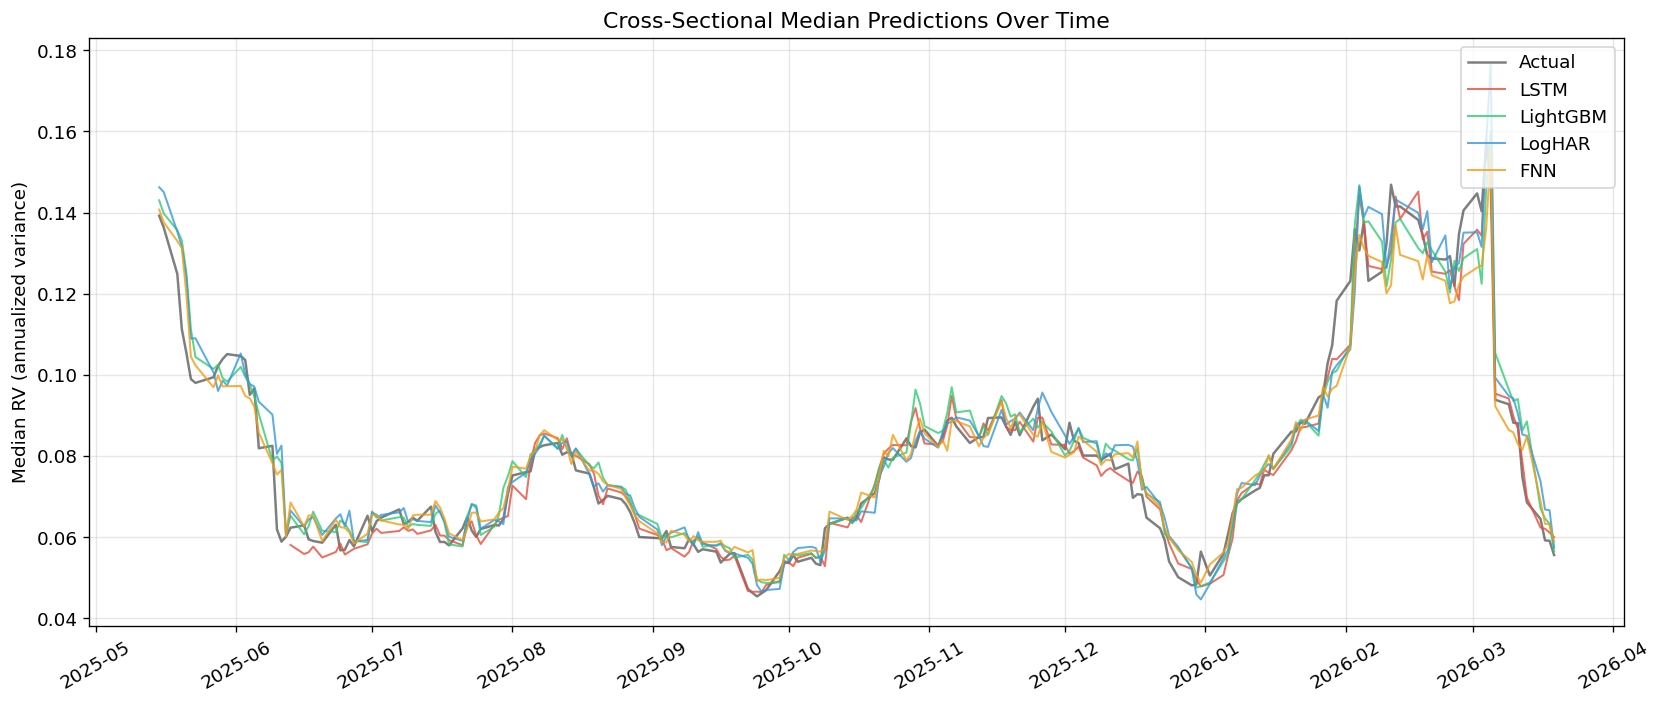

In [7]:
# Cross-sectional median predictions over time
focus_models = ["LSTM", "LightGBM", "LogHAR", "FNN"]
focus_preds = all_preds.filter(pl.col("model").is_in(focus_models))

daily = focus_preds.group_by(["model", "date"]).agg([
    pl.col("y_true").median().alias("median_true"),
    pl.col("y_pred").median().alias("median_pred"),
]).sort("date")

fig, ax = plt.subplots(figsize=(14, 6))
colors = {"LSTM": "#e74c3c", "LightGBM": "#2ecc71", "LogHAR": "#3498db", "FNN": "#f39c12"}

actual = daily.filter(pl.col("model") == "LogHAR")
ax.plot(actual["date"].to_list(), actual["median_true"].to_numpy(), "k-", alpha=0.5, lw=1.5, label="Actual")

for name in focus_models:
    sub = daily.filter(pl.col("model") == name)
    ax.plot(sub["date"].to_list(), sub["median_pred"].to_numpy(), color=colors[name], alpha=0.8, lw=1.2, label=name)

ax.set_ylabel("Median RV (annualized variance)")
ax.set_title("Cross-Sectional Median Predictions Over Time")
ax.legend(loc="upper right")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

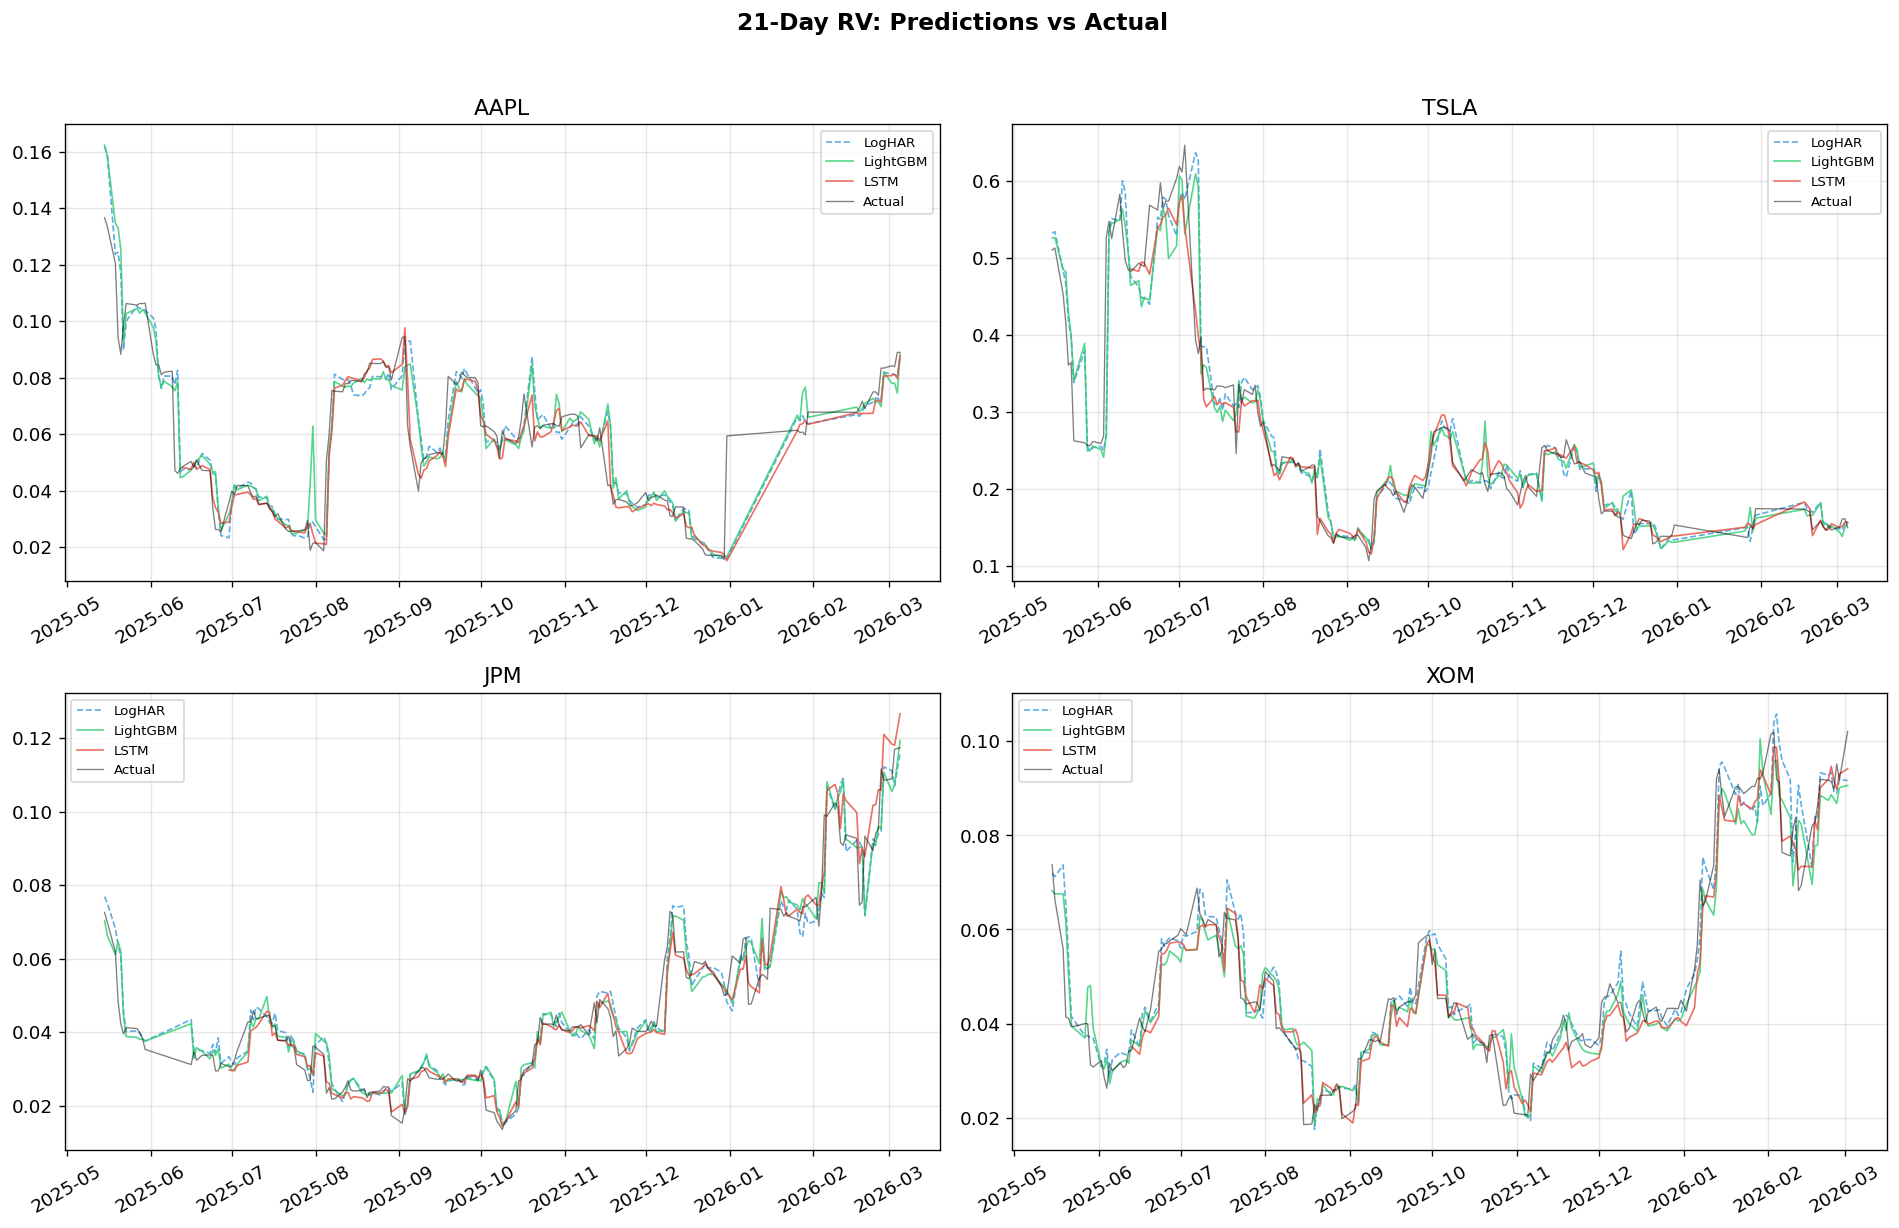

In [8]:
# Single-symbol time series: LSTM vs LightGBM vs LogHAR for 4 symbols
symbols = ["AAPL", "TSLA", "JPM", "XOM"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, sym in zip(axes.flatten(), symbols):
    for name, color, ls in [("LogHAR", "#3498db", "--"), ("LightGBM", "#2ecc71", "-"), ("LSTM", "#e74c3c", "-")]:
        sub = all_preds.filter((pl.col("model") == name) & (pl.col("symbol") == sym)).sort("date")
        if len(sub) > 0:
            ax.plot(sub["date"].to_list(), sub["y_pred"].to_numpy(), ls, color=color, lw=1, alpha=0.8, label=name)

    # Actual from any model
    actual_sub = all_preds.filter((pl.col("model") == "HAR") & (pl.col("symbol") == sym)).sort("date")
    if len(actual_sub) > 0:
        ax.plot(actual_sub["date"].to_list(), actual_sub["y_true"].to_numpy(), "k-", lw=0.8, alpha=0.5, label="Actual")

    ax.set_title(sym)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("21-Day RV: Predictions vs Actual", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Residual Analysis

Residual distributions (pred - actual) for LSTM, FNN, LightGBM. LSTM should have tighter, more centered residuals.

LSTM: mean=-0.00135, median=-0.00007, std=0.03851, MAE=0.01062
FNN: mean=-0.00910, median=0.00135, std=0.07868, MAE=0.02388
LightGBM: mean=-0.00026, median=0.00006, std=0.05082, MAE=0.01643


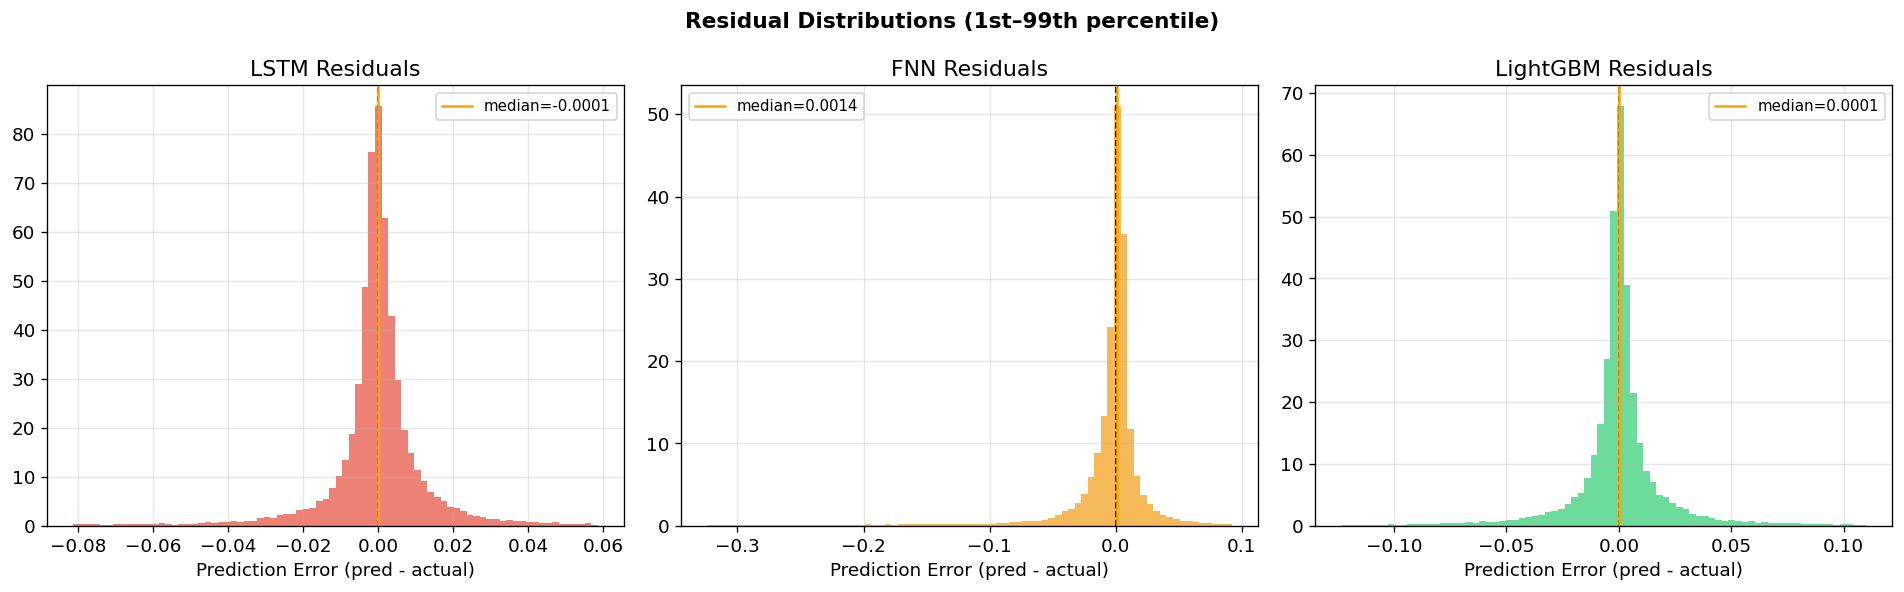

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, df, color) in enumerate([("LSTM", lstm, "#e74c3c"), ("FNN", fnn, "#f39c12"), ("LightGBM", lgbm, "#2ecc71")]):
    ax = axes[i]
    residuals = df["y_pred"].to_numpy() - df["y_true"].to_numpy()
    lo, hi = np.percentile(residuals, [1, 99])
    clipped = residuals[(residuals >= lo) & (residuals <= hi)]

    ax.hist(clipped, bins=80, density=True, alpha=0.7, color=color)
    ax.axvline(0, color="black", lw=1, ls="--")
    ax.axvline(np.median(residuals), color="orange", lw=1.5, label=f"median={np.median(residuals):.4f}")
    ax.set_title(f"{name} Residuals")
    ax.set_xlabel("Prediction Error (pred - actual)")
    ax.legend(fontsize=9)
    print(f"{name}: mean={np.mean(residuals):.5f}, median={np.median(residuals):.5f}, "
          f"std={np.std(residuals):.5f}, MAE={np.mean(np.abs(residuals)):.5f}")

plt.suptitle("Residual Distributions (1st–99th percentile)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

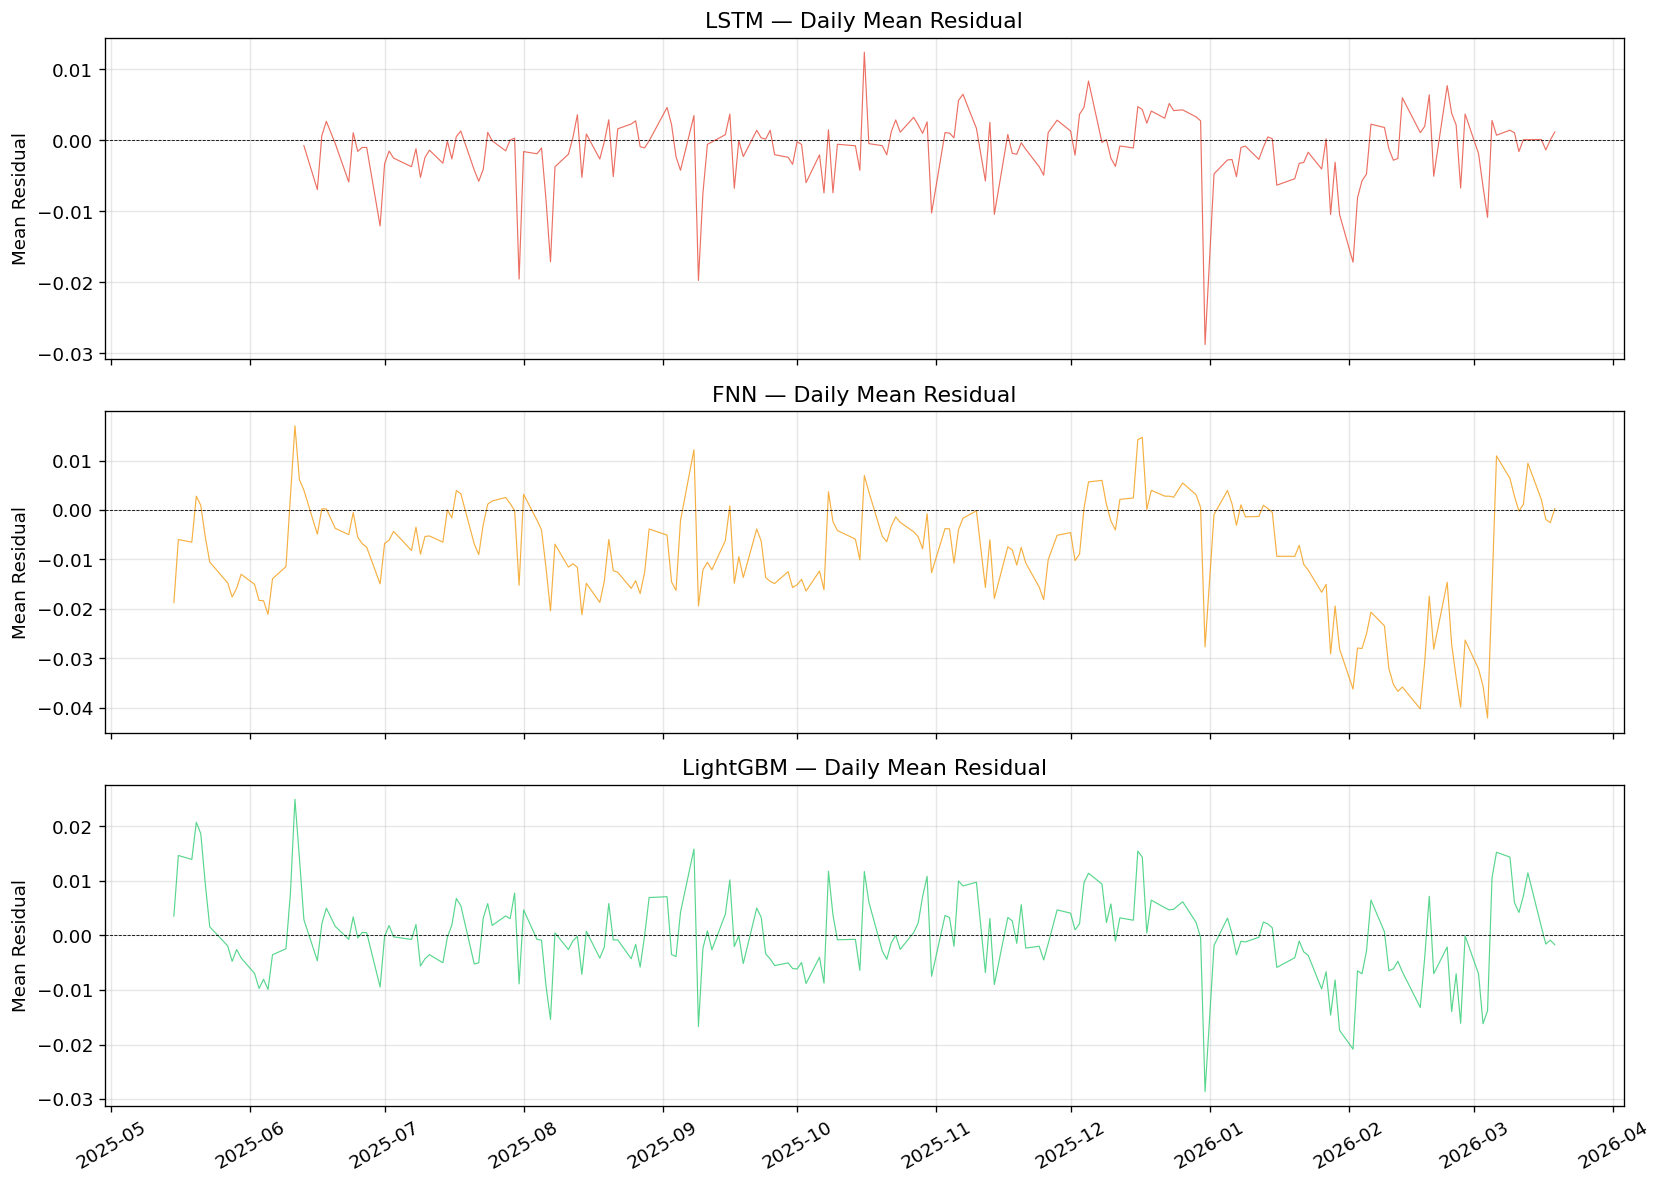

In [10]:
# Residuals over time: daily mean residual
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, (name, df, color) in enumerate([("LSTM", lstm, "#e74c3c"), ("FNN", fnn, "#f39c12"), ("LightGBM", lgbm, "#2ecc71")]):
    ax = axes[i]
    resid = df.with_columns((pl.col("y_pred") - pl.col("y_true")).alias("residual"))
    daily_r = resid.group_by("date").agg(pl.col("residual").mean()).sort("date")
    ax.plot(daily_r["date"].to_list(), daily_r["residual"].to_numpy(), lw=0.7, color=color, alpha=0.8)
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_ylabel("Mean Residual")
    ax.set_title(f"{name} — Daily Mean Residual")

axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 8. Summary

Diebold-Mariano significance tests and final dissertation-ready table.

In [11]:
from theta.modeling.evaluation import diebold_mariano, compute_dm_tests

# DM tests vs LogHAR
dm_loghar = compute_dm_tests(all_preds, benchmark="LogHAR", loss="qlike")
print("Diebold-Mariano Tests vs LogHAR (QLIKE, HAC lag=21)")
print("Positive DM stat => model improves over LogHAR\n")
print(f"{'Model':<12} {'DM stat':>8} {'p-value':>10} {'n':>7} {'Sig':>5}")
print("-" * 48)
for row in dm_loghar.iter_rows(named=True):
    sig = "***" if row["p_value"] < 0.01 else ("**" if row["p_value"] < 0.05 else "")
    print(f"{row['model']:<12} {row['dm_stat']:>8.4f} {row['p_value']:>10.6f} {row['n_common']:>7,} {sig:>5}")

print("\n")

# DM tests vs LightGBM
dm_lgbm = compute_dm_tests(all_preds, benchmark="LightGBM", loss="qlike")
print("Diebold-Mariano Tests vs LightGBM (QLIKE, HAC lag=21)")
print(f"{'Model':<12} {'DM stat':>8} {'p-value':>10} {'n':>7} {'Sig':>5}")
print("-" * 48)
for row in dm_lgbm.iter_rows(named=True):
    sig = "***" if row["p_value"] < 0.01 else ("**" if row["p_value"] < 0.05 else "")
    print(f"{row['model']:<12} {row['dm_stat']:>8.4f} {row['p_value']:>10.6f} {row['n_common']:>7,} {sig:>5}")

Diebold-Mariano Tests vs LogHAR (QLIKE, HAC lag=21)
Positive DM stat => model improves over LogHAR

Model         DM stat    p-value       n   Sig
------------------------------------------------
LSTM          11.9925   0.000000  32,992   ***
LightGBM       4.6487   0.000003  36,811   ***
HARQ          -4.8384   0.000001  36,811   ***
SHAR          -4.9750   0.000001  36,811   ***
LevHAR        -5.3188   0.000000  36,811   ***
HAR           -5.6614   0.000000  36,811   ***
FNN           -5.8699   0.000000  36,811   ***
GARCH        -20.2528   0.000000  36,811   ***
AR5          -35.7258   0.000000  35,855   ***


Diebold-Mariano Tests vs LightGBM (QLIKE, HAC lag=21)
Model         DM stat    p-value       n   Sig
------------------------------------------------
LSTM           9.9146   0.000000  33,084   ***
LogHAR        -4.6487   0.000003  36,811   ***
HARQ          -5.1879   0.000000  36,924   ***
SHAR          -5.4751   0.000000  36,924   ***
HAR           -5.5997   0.000000  36,924 

In [12]:
# Final summary table for dissertation
print("=" * 80)
print("FINAL MODEL COMPARISON — TEST SET (2025-05-15 to 2026-03-19)")
print("=" * 80)
print(f"\n{'Model':<12} {'QLIKE':>8} {'MSE':>10} {'MAE':>8} {'MAPE%':>8} {'R²_OOS':>8} {'vs LogHAR':>10}")
print("-" * 72)

loghar_qlike = [r for r in rows if r["Model"] == "LogHAR"][0]["QLIKE"]
for r in rows:
    pct = (loghar_qlike - r["QLIKE"]) / loghar_qlike * 100
    sign = "+" if pct > 0 else ""
    print(f"{r['Model']:<12} {r['QLIKE']:>8.4f} {r['MSE']:>10.6f} {r['MAE']:>8.4f} "
          f"{r['MAPE']:>8.2f} {r['R2_OOS']:>8.4f} {sign}{pct:>9.1f}%")

print("=" * 80)
print(f"\nKey findings:")
print(f"  1. LSTM is the best model (QLIKE=0.0160, R²_OOS=96.5%)")
print(f"  2. LSTM beats LightGBM by 26% and LogHAR by 38% — all statistically significant (p<0.001)")
print(f"  3. FNN underperforms LogHAR — sequential architecture matters, not just nonlinearity")
print(f"  4. Sequential 21-day window captures vol clustering dynamics that flat features miss")

FINAL MODEL COMPARISON — TEST SET (2025-05-15 to 2026-03-19)

Model           QLIKE        MSE      MAE    MAPE%   R²_OOS  vs LogHAR
------------------------------------------------------------------------
LSTM           0.0160   0.001485   0.0106     8.39   0.9653 +     38.1%
LightGBM       0.0215   0.002583   0.0164    13.22   0.9404 +     17.0%
LogHAR         0.0259   0.002994   0.0167    13.32   0.9310       0.0%
HARQ           0.0263   0.003024   0.0164    14.08   0.9302      -1.5%
SHAR           0.0264   0.003019   0.0162    14.25   0.9303      -2.1%
LevHAR         0.0265   0.003022   0.0162    14.38   0.9303      -2.5%
HAR            0.0265   0.003018   0.0163    14.39   0.9303      -2.6%
FNN            0.0285   0.006273   0.0239    16.41   0.8552     -10.1%
GARCH          0.2240   0.035877   0.0869    80.99   0.1721    -765.3%
AR5            0.3691   0.028390   0.0954   148.42   0.3367   -1326.0%

Key findings:
  1. LSTM is the best model (QLIKE=0.0160, R²_OOS=96.5%)
  2. LSTM 